## Restaurant Review Sentiment Analysis (NLP)
This project applies Natural Language Processing (NLP) techniques to classify Restaurant reviews as positive or negative using Python and machine learning.

## Objective
Customer reviews provide valuable insights into product quality and customer satisfaction. The goal of this project is to build a machine learning model that can automatically classify Restaurant reviews as positive or negative.

This can help companies monitor customer feedback at scale and quickly identify potential issues with products or services.

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import nltk #natural language toolkit
import string #provides useful constants and functions related to string handling
import re
import string
import matplotlib.pyplot as plt
import shap

from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize #used to split text into individual words (tokens)
from nltk.corpus import stopwords #This imports the stopwords corpus from NLTK.
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer #used to convert a collection of text documents into a matrix of token counts
from sklearn.feature_extraction.text import TfidfVectorizer # it represents text in terms of Term Frequency-Inverse Document Frequency (TF-IDF)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score # Importing necessary functions
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Dataset

In [4]:
# Importing the dataset
df = pd.read_csv('restaurant reviews.csv', encoding='latin1')

In [5]:
#check data
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [6]:
#check number of rows and columns
df.shape

(1000, 2)

In [7]:
# Calculate value counts for reviews
df['Liked'].value_counts()

,count
Liked,
1,500
0,500


In [8]:
# checking data types
df.dtypes

,0
Review,object
Liked,int64


#Label Encoding


In [9]:
#save the labels and encode them as 1 and 0 for future classification/clustering
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(df['Liked'])
print(label[:10])
print(df['Liked'][:10])

[1 0 0 1 1 0 0 0 1 1]
0    1
1    0
2    0
3    1
4    1
5    0
6    0
7    0
8    1
9    1
Name: Liked, dtype: int64


In [10]:
#changing the text column datatype to string
df = df.astype({'Review':'string'})

In [11]:
df.dtypes

,0
Review,string[python]
Liked,int64


In [12]:
#extract the review text for preprocessing
text = df['Review']
text[:10]

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...
5,Now I am getting angry and I want my damn pho.
6,Honeslty it didn't taste THAT fresh.)
7,The potatoes were like rubber and you could te...
8,The fries were great too.
9,A great touch.


#Data Pre-processing

1. Remove special characters

In [13]:
# Define a function to remove specific special characters
def remove_special_characters(text):
    # Replace $, %, *, and # with an empty string
    return re.sub(r'[\$\%\*\#]', '', text)

# Create an empty list to store the cleaned data
text1 = []

# Process each line in the text
for line in text:
    # Clean each line and add it to the list
    cleaned_line = remove_special_characters(line)
    text1.append(cleaned_line)

text1[:5]

['Wow... Loved this place.',
 'Crust is not good.',
 'Not tasty and the texture was just nasty.',
 'Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.',
 'The selection on the menu was great and so were the prices.']

2. Removing Punctuation

In [14]:
# Creating an empty list to store the cleaned versions of the reviews
text2 = []

import string

# Iterate through each review in the text list and remove punctuation
for review in text1:
    review = review.translate(str.maketrans('', '', string.punctuation))
    text2.append(review)

# Check the first 10 reviews after removing punctuation
text2[:5]

['Wow Loved this place',
 'Crust is not good',
 'Not tasty and the texture was just nasty',
 'Stopped by during the late May bank holiday off Rick Steve recommendation and loved it',
 'The selection on the menu was great and so were the prices']

3. Removing Numbers

In [15]:
# Create a new list to store reviews with digits removed
text3 = []

# Iterate through the reviews in text1 and remove digits
for review in text2:
    review = review.translate(str.maketrans('', '', string.digits))
    text3.append(review)

# Check the first 5 reviews after removing digits
text3[:5]

['Wow Loved this place',
 'Crust is not good',
 'Not tasty and the texture was just nasty',
 'Stopped by during the late May bank holiday off Rick Steve recommendation and loved it',
 'The selection on the menu was great and so were the prices']

4. Converting to lowercase

In [16]:
# Create a new list to store reviews in lowercase
text4 = []

# Iterate through the reviews in text2 and convert to lowercase
for review in text3:
    review = review.lower()
    text4.append(review)

# Check the first 5 reviews after converting to lowercase
text4[:5]

['wow loved this place',
 'crust is not good',
 'not tasty and the texture was just nasty',
 'stopped by during the late may bank holiday off rick steve recommendation and loved it',
 'the selection on the menu was great and so were the prices']

5. Remove stop words

In [17]:
text4 = pd.Series(text4)
text4[:5]

,0
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...


In [18]:
#remove stop words

#Setting English stopwords
stop_words = set(stopwords.words('english'))

text5 = text4.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))
text5[:5]

,0
0,wow loved place
1,crust good
2,tasty texture nasty
3,stopped late may bank holiday rick steve recom...
4,selection menu great prices


6. Lemmatising

In [19]:
#apply lemmatising with POS tags

def get_wordnet_pos(word):
    #Map POS tag to first character lemmatize() accepts
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

# Init the Wordnet Lemmatizer
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()
text6 = text5.apply(lambda x:' '.join(lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in x.split()))
text6[:5]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,0
0,wow love place
1,crust good
2,tasty texture nasty
3,stop late may bank holiday rick steve recommen...
4,selection menu great price


In [20]:
#This code is focused on creating a pandas DataFrame from the preprocessed text and sentiment labels
reviews1 = list(zip(text6, label))

reviewsP = pd.DataFrame (reviews1, columns = ['Review', 'Sentiment'])
reviewsP

,Review,Sentiment
0,wow love place,1
1,crust good,0
2,tasty texture nasty,0
3,stop late may bank holiday rick steve recommen...,1
4,selection menu great price,1
...,...,...
995,think food flavor texture lack,0
996,appetite instantly go,0
997,overall impressed would go back,0
998,whole experience underwhelming think well go n...,0


#**Classification**

In [21]:
reviewsP.head()

,Review,Sentiment
0,wow love place,1
1,crust good,0
2,tasty texture nasty,0
3,stop late may bank holiday rick steve recommen...,1
4,selection menu great price,1


In [22]:
# Shuffling the data to prevent any ordering to have an effect on the performance
reviewsP1 = reviewsP.sample(frac=1, random_state=1).reset_index()
reviewsP1.head()

,index,Review,Sentiment
0,507,gyro basically lettuce,0
1,818,kept get bad bad im officially do,0
2,452,far sushi connoisseur definitely tell differen...,0
3,368,staff great ambiance great,1
4,242,time side restaurant almost empty excuse,0


In [23]:
#splitting the dataset

#train dataset by splitting the data
train_reviews = reviewsP1.Review[:800]
train_sentiments = reviewsP1.Sentiment[:800]

#test dataset
test_reviews = reviewsP1.Review[800:]
test_sentiments = reviewsP1.Sentiment[800:]

print(train_reviews.shape,train_sentiments.shape)
print(test_reviews.shape,test_sentiments.shape)

(800,) (800,)
(200,) (200,)


In [24]:
train_reviews[0]

'gyro basically lettuce'

In [25]:
# Check class distribution in training data
print(train_sentiments.value_counts())

Sentiment
0    400
1    400
Name: count, dtype: int64


Bag of words

In [26]:
#Count vectorizer for bag of words
#cv=CountVectorizer(min_df=0,max_df=1,binary=False,ngram_range=(1,3))
cv=CountVectorizer()

#transformed train reviews
cv_train_reviews=cv.fit_transform(train_reviews)
#transformed test reviews
cv_test_reviews=cv.transform(test_reviews)

print('BOW_cv_train:',cv_train_reviews.shape)
print('BOW_cv_test:',cv_test_reviews.shape)

vocab=cv.get_feature_names_out() #toget feature names

BOW_cv_train: (800, 1453)
BOW_cv_test: (200, 1453)


In [27]:
print(cv_train_reviews[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 1453)>
  Coords	Values
  (0, 575)	1
  (0, 97)	1
  (0, 734)	1


In [28]:
X_train = cv_train_reviews
y_train = train_sentiments

#Decision Tree

In [29]:
# Initialize the DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Cross-validation for Bag of Words
cv_bow_scores = cross_val_score(DT, X_train, y_train, cv=5, scoring='accuracy')
print("DT_bow accuracy:", np.mean(cv_bow_scores))

# Get predictions for Bag of Words using cross-validation
DT_bow_predictions = cross_val_predict(DT, X_train, y_train, cv=5)

# Confusion Matrix and Classification Report for Bag of Words
print("\nConfusion Matrix for Bag of Words:")
print(confusion_matrix(y_train, DT_bow_predictions))
print("\nClassification Report for Bag of Words:")
print(classification_report(y_train, DT_bow_predictions, target_names=['Negative', 'Positive']))

# ROC AUC for Bag of Words
roc_auc_bow = roc_auc_score(y_train, DT_bow_predictions)
print(f"\nROC AUC for Bag of Words: {roc_auc_bow:.4f}")


DT_bow accuracy: 0.70125

Confusion Matrix for Bag of Words:
[[300 100]
 [139 261]]

Classification Report for Bag of Words:
              precision    recall  f1-score   support

    Negative       0.68      0.75      0.72       400
    Positive       0.72      0.65      0.69       400

    accuracy                           0.70       800
   macro avg       0.70      0.70      0.70       800
weighted avg       0.70      0.70      0.70       800


ROC AUC for Bag of Words: 0.7012


#KNN

In [30]:
# Initialize the KNeighborsClassifier
kNN = KNeighborsClassifier(n_neighbors=7)

# Cross-validation for Bag of Words
cv_bow_scores = cross_val_score(kNN, X_train, y_train, cv=5, scoring='accuracy')
print("kNN_bow accuracy:", np.mean(cv_bow_scores))

# Get predictions from cross-validation for Bag of Words
kNN_bow_predictions = cross_val_predict(kNN, X_train, y_train, cv=5)

# Confusion Matrix and Classification Report for Bag of Words
print("\nConfusion Matrix for Bag of Words:")
print(confusion_matrix(y_train, kNN_bow_predictions))
print("\nClassification Report for Bag of Words:")
print(classification_report(y_train, kNN_bow_predictions, target_names=['Negative', 'Positive']))

# Get probability predictions for Bag of Words
kNN_bow_probabilities = cross_val_predict(kNN, X_train, y_train, cv=5, method='predict_proba')

# Calculate ROC AUC score
roc_auc_bow = roc_auc_score(y_train, kNN_bow_probabilities[:, 1])  # Use probabilities for the positive class
print("\nkNN_bow ROC AUC:", roc_auc_bow)

kNN_bow accuracy: 0.6325000000000001

Confusion Matrix for Bag of Words:
[[260 140]
 [154 246]]

Classification Report for Bag of Words:
              precision    recall  f1-score   support

    Negative       0.63      0.65      0.64       400
    Positive       0.64      0.61      0.63       400

    accuracy                           0.63       800
   macro avg       0.63      0.63      0.63       800
weighted avg       0.63      0.63      0.63       800


kNN_bow ROC AUC: 0.68309375


#Naive Bayes (Best Model)

In [31]:
# Initialize the Multinomial Naive Bayes classifier
NB = MultinomialNB()

# Cross-validation for Bag of Words (Accuracy)
cv_bow_scores = cross_val_score(NB, X_train, y_train, cv=5, scoring='accuracy')
print("NB_bow accuracy:", np.mean(cv_bow_scores))

# Get predictions from cross-validation for Bag of Words
NB_bow_predictions = cross_val_predict(NB, X_train, y_train, cv=5)

# Confusion Matrix and Classification Report for Bag of Words
print("\nConfusion Matrix for Bag of Words:")
print(confusion_matrix(y_train, NB_bow_predictions))
print("\nClassification Report for Bag of Words:")
print(classification_report(y_train, NB_bow_predictions, target_names=['Negative', 'Positive']))

# Get probability predictions for Bag of Words
NB_bow_probabilities = cross_val_predict(NB, X_train, y_train, cv=5, method='predict_proba')

# Calculate ROC AUC score
roc_auc_bow = roc_auc_score(y_train, NB_bow_probabilities[:, 1])  # Use probabilities for the positive class
print("\nNB_bow ROC AUC:", roc_auc_bow)

NB_bow accuracy: 0.7550000000000001

Confusion Matrix for Bag of Words:
[[286 114]
 [ 82 318]]

Classification Report for Bag of Words:
              precision    recall  f1-score   support

    Negative       0.78      0.71      0.74       400
    Positive       0.74      0.80      0.76       400

    accuracy                           0.76       800
   macro avg       0.76      0.76      0.75       800
weighted avg       0.76      0.76      0.75       800


NB_bow ROC AUC: 0.84343125


#Random Forest

In [32]:
# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross-validation for Bag of Words (Accuracy)
cv_bow_scores = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest_bow accuracy:", np.mean(cv_bow_scores))

# Get predicted probabilities from cross-validation for Bag of Words
rf_bow_probabilities = cross_val_predict(rf_clf, X_train, y_train, cv=5, method='predict_proba')

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_train, rf_bow_probabilities[:, 1])  # Get probabilities for the positive class
print("\nROC AUC Score for Bag of Words:", roc_auc)

# Get predictions from cross-validation for Bag of Words
rf_bow_predictions = cross_val_predict(rf_clf, X_train, y_train, cv=5)

# Confusion Matrix and Classification Report for Bag of Words
print("\nConfusion Matrix for Bag of Words:")
print(confusion_matrix(y_train, rf_bow_predictions))
print("\nClassification Report for Bag of Words:")
print(classification_report(y_train, rf_bow_predictions, target_names=['Negative', 'Positive']))

Random Forest_bow accuracy: 0.72125

ROC AUC Score for Bag of Words: 0.8207406250000001

Confusion Matrix for Bag of Words:
[[330  70]
 [153 247]]

Classification Report for Bag of Words:
              precision    recall  f1-score   support

    Negative       0.68      0.82      0.75       400
    Positive       0.78      0.62      0.69       400

    accuracy                           0.72       800
   macro avg       0.73      0.72      0.72       800
weighted avg       0.73      0.72      0.72       800



#SHAP

In [46]:
cv = CountVectorizer(max_features=500)

In [47]:
X_train = cv.fit_transform(train_reviews)

PermutationExplainer explainer: 801it [03:48,  3.48it/s]
/tmp/ipykernel_12303/648864799.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_train_dense, feature_names=cv.get_feature_names_out())


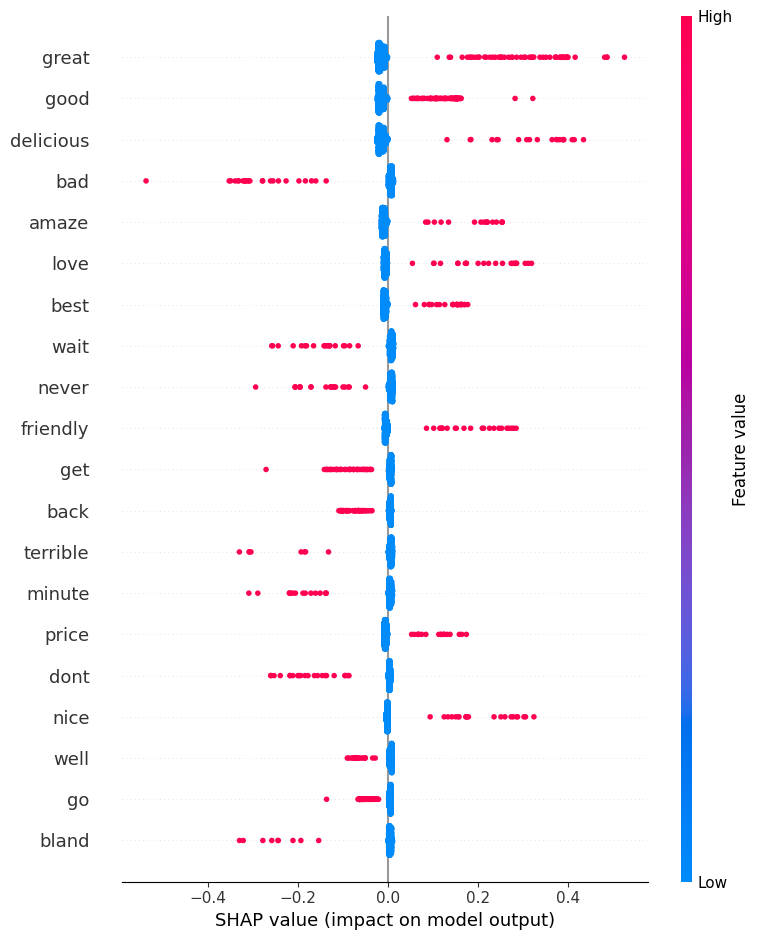

In [48]:
NB.fit(X_train, y_train)

import shap

X_train_dense = X_train.toarray()

explainer = shap.Explainer(NB.predict_proba, X_train_dense)
shap_values = explainer(X_train_dense)

shap.summary_plot(shap_values[:, :, 1], X_train_dense, feature_names=cv.get_feature_names_out())

# Word Cloud

In [50]:
!pip install wordcloud

In [51]:
all_text = " ".join(train_reviews)

In [52]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

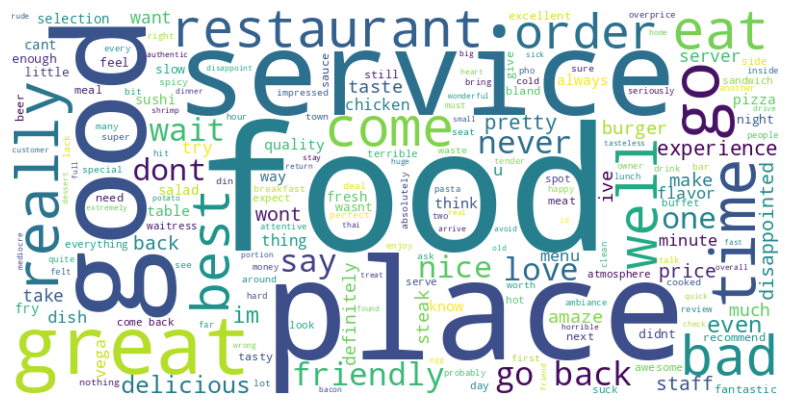

In [53]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Word cloud for Positive reviews

In [54]:
positive_text = " ".join([review for review, label in zip(train_reviews, y_train) if label == 1])

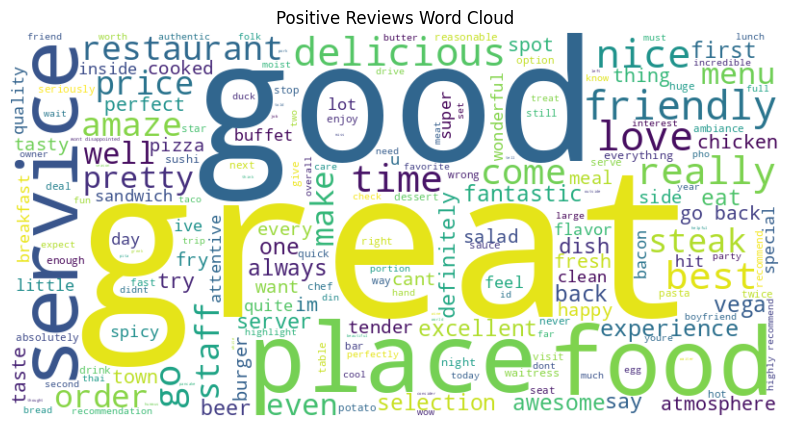

In [57]:
# Positive word cloud
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

Word cloud for Negative reviews

In [55]:
negative_text = " ".join([review for review, label in zip(train_reviews, y_train) if label == 0])

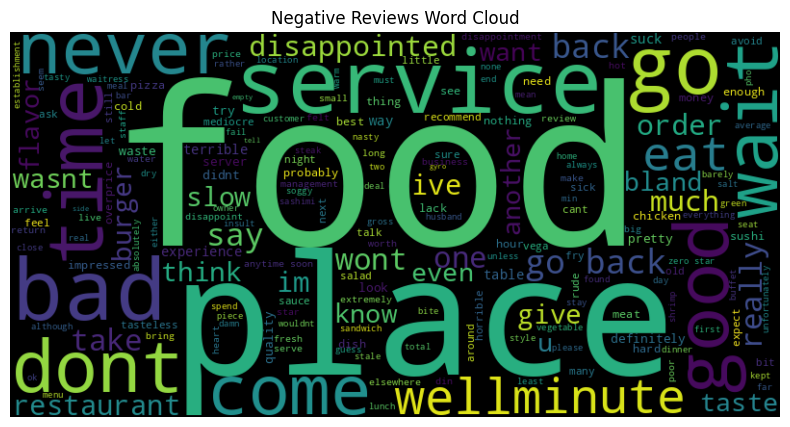

In [58]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()